# Numerical Verification of the Arrow Sufficient Condition in Judd (1985)
> Written by George Chou, August 18, 2026.

## Model Description and Arrow Sufficiency Condition

### (1) The Economy

We study the discrete-time, two-class economy without government debt, as formulated in Judd (1985) and revisited by Straub and Werning (2020). The economy consists of:

- **Capitalists**: They own the capital stock, save optimally, and derive utility from consumption $C_t$. Their preferences are isoelastic:
  $$U(C) = \frac{C^{1-\sigma}}{1-\sigma}$$
  where $\sigma > 0$ is the inverse of the elasticity of intertemporal substitution.

- **Workers**: They supply one unit of labor inelastically each period, consume their entire disposable income (wages plus government transfers), and do not save. Their utility is $u(c_t)$.

- **Technology**: Output is produced via a neoclassical constant-returns production function $f(k) = k^\alpha$. Capital depreciates at rate $\delta$. The government consumes a constant flow $g > 0$ and runs a balanced budget (no government debt).

### (2) The Planning Problem

The government maximizes a weighted sum of utilities, with weight $\gamma \ge 0$ on capitalists. For the case of redistribution from capitalists to workers, we set $\gamma = 0$. The planner's problem is:

$$
\max_{\{c_t, C_t, k_{t+1}\}} \sum_{t=0}^{\infty} \beta^t u(c_t)
$$

subject to the resource constraint:
$$
c_t + C_t + g + k_{t+1} = f(k_t) + (1 - \delta)k_t,
$$

and the capitalists' Euler equation combined with their budget constraint:
$$
\beta U'(C_t)(C_t + k_{t+1}) = U'(C_{t-1}) k_t,
$$

with $k_0$ given and the transversality condition $\lim_{t \to \infty} \beta^t U'(C_t) k_{t+1} = 0$.

### (3) Optimal Control Formulation

To apply optimal control theory, we define the **state variables** as:
- $k_t$: current capital stock,
- $z_t = C_{t-1}$: capitalists' consumption in the previous period.

The **control variables** are $(c_t, C_t, k_{t+1})$.

The current-value Lagrangian (Hamiltonian) for this problem is:

$$
\mathcal{H}_t = u(c_t) + \lambda_{t+1} \big[ f(k_t) + (1-\delta)k_t - c_t - C_t - g - k_{t+1} \big] + \mu_t \big[ \beta U'(C_t)(C_t + k_{t+1}) - U'(C_{t-1}) k_t \big],
$$

where $\lambda_{t+1}$ is the multiplier on the resource constraint and $\mu_t$ is the multiplier on the Euler-equation constraint.

### (4) The Maximised Hamiltonian and Arrow's Sufficiency Condition

After maximizing $\mathcal{H}_t$ with respect to the control variables $(c_t, C_t, k_{t+1})$, we obtain the **maximised Hamiltonian**, denoted $H^0(k_t, C_{t-1})$. Up to an additive constant, its effective part is:

$$
\tilde{H}^0(k, z) = A \big[ f(k) + (1-\delta)k \big] - \mu \, z^{-\sigma} k,
$$

where $z = C_{t-1}$, $\mu$ is the multiplier on the Euler constraint, and $A = \mu \beta (C^*)^{- \sigma}$ (evaluated using the steady-state values for our numerical local check).

**Arrow's Sufficiency Condition** states that if the maximised Hamiltonian $H^0(k, z)$ is concave in the state variables $(k, z)$ along a candidate path that satisfies the first-order conditions and transversality conditions, then that path is a global optimum.

For a twice-differentiable function, concavity requires its Hessian matrix to be negative semi-definite. For our two-state system, this is equivalent to the following two conditions holding **simultaneously**:

1. **First principal minor**:
   $$H_{kk} = \frac{\partial^2 \tilde{H}^0}{\partial k^2} = A \, f''(k) < 0.$$

2. **Second principal minor (determinant)**:
   $$
   \det(H) = H_{kk} H_{zz} - (H_{kz})^2 > 0,
   $$
   where
   $$
   H_{zz} = \frac{\partial^2 \tilde{H}^0}{\partial z^2} = -\mu \, \sigma (\sigma+1) \, z^{-\sigma-2} \, k,
   $$
   and
   $$
   H_{kz} = \frac{\partial^2 \tilde{H}^0}{\partial k \partial z} = -\mu \, \sigma \, z^{-\sigma-1}.
   $$

If both inequalities hold strictly at a point, the maximised Hamiltonian is locally strictly concave there, and Arrow's sufficient condition is satisfied locally.

### (5) Numerical Verification

In this notebook, we numerically evaluate these Hessian elements on a grid spanning the entire feasible state space (from the lower sustainable capital $k_g$ to the upper sustainable capital $k^g$). We use the steady-state multiplier $\mu^*$ (derived from the first-order conditions) to compute $H_{kk}$, $H_{zz}$, $H_{kz}$, and the determinant $\det(H)$. By plotting the region where both $H_{kk} < 0$ and $\det(H) > 0$, we visually verify whether Arrow's condition supports the zero-tax steady state for different values of the IES parameter $\sigma$.

## 1. Paramaterization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

beta = 0.95          # discount factor
delta = 0.1          # depreciation rate
alpha = 0.3          # capital share in Cobb-Douglas production
sigma = 0.75         # inverse of IES.
epsilon = 1e-12      # small number to avoid numerical blow-up near zero

## 2. Defining Functions

In [69]:
def f(k):
    """Cobb-Douglas production function f(k) = k^alpha."""
    return np.power(k, alpha)

def f_prime(k):
    """First derivative of f."""
    return alpha * np.power(k, alpha - 1.0)

def f_double_prime(k):
    """Second derivative of f."""
    return alpha * (alpha - 1.0) * np.power(k, alpha - 2.0)

def U_prime(C):
    """Marginal utility of capitalists' consumption (isoelastic)."""
    return np.power(C, -sigma)

## 3. Zero-Tax Steady State
Zero-tax steady state satisfies the modified golden rule
$$
f'(k^*) + 1 - \delta = \frac{1}{\beta},
$$
and
$$
C^* = \frac{1-\beta}{\beta} k^*.
$$

Government spending level is chosen so that $g / f(k^*) = 0.20$.

In [84]:
k_star = (alpha / (1.0/beta - 1.0 + delta)) ** (1.0 / (1.0 - alpha))
f_k_star = f(k_star)
g = 0.20 * f_k_star

C_star = (1.0 - beta) / beta * k_star
c_star = f_k_star + (1.0 - delta) * k_star - C_star - g

# Multipliers at the steady state
nu_star = U_prime(C_star) / (np.power(c_star, -sigma))

# Note: mu_star formula requires sigma != 1. For sigma=1, the log case is special.
if np.isclose(sigma, 1.0):
    raise ValueError("sigma = 1 (log utility) is a boundary case; "
                     "the formula for mu_star divides by zero. "
                     "Please use sigma != 1 for this numerical exercise.")

mu_star = -1.0 / ((sigma - 1.0) * beta * nu_star)

# Print steady-state values for verification
print("=" * 50)
print("STEADY-STATE VALUES")
print("=" * 50)
print(f"k*  = {k_star:.6f}")
print(f"c*  = {c_star:.6f}")
print(f"C*  = {C_star:.6f}")
print(f"g   = {g:.6f}")
print(f"nu* = {nu_star:.6f}")
print(f"mu* = {mu_star:.6f}")
print("=" * 50)

STEADY-STATE VALUES
k*  = 2.625746
c*  = 3.293698
C*  = 0.138197
g   = 0.267181
nu* = 10.786700
mu* = 0.390344


## 4. Calculating the Grid Boundaries
We define the function whose roots are the sustainable capital levels such that
$$
f(k) - (1/\beta - 1 + \delta)k - g = 0,
$$
and find the roots.

In [85]:
def root_func(k):
    return f(k) - (1.0/beta - 1.0 + delta) * k - g

# Lower root k_g: lies between a tiny positive number and the zero-tax steady state k_star
# Note: h(0+) = -g < 0, and h(k_star) = (1 - alpha - 0.2)*f(k_star) > 0 (for alpha=0.3)
k_g = bisect(root_func, 1e-9, k_star)

# Upper root k^g: lies between k_star and a sufficiently large number.
# Find an upper bound by doubling until the function becomes negative.
upper_bound = k_star * 2.0
while root_func(upper_bound) > 0:
    upper_bound *= 2.0
k_sup = bisect(root_func, k_star, upper_bound)

# Print results (relative to steady state k*)
print("\n" + "=" * 50)
print("SUSTAINABLE CAPITAL ROOTS (k_g and k^g)")
print("=" * 50)
print(f"k_g (lower root) = {k_g:.8f}  (≈ {k_g / k_star:.4f} × k*)")
print(f"k^g (upper root)= {k_sup:.8f}  (≈ {k_sup / k_star:.4f} × k*)")
print("=" * 50 + "\n")


SUSTAINABLE CAPITAL ROOTS (k_g and k^g)
k_g (lower root) = 0.01258114  (≈ 0.0048 × k*)
k^g (upper root)= 12.08669024  (≈ 4.6031 × k*)



## 5. Constructing the Grid Points

In [86]:
n_points = 3000

# Set grid boundaries to the roots
k_min = k_g
k_max = k_sup

# From the steady-state relation: C = ((1 - beta)/beta) * k
# This holds for any steady state (including these boundary ones).
z_min = k_min * (1.0 - beta) / beta + 0.1
z_max = k_max * (1.0 - beta) / beta
print(f"Corresponding C range: [{z_min:.6f}, {z_max:.6f}]")

# Create 1D coordinate vectors
k_vec = np.linspace(k_min, k_max, n_points)
z_vec = np.linspace(z_min, z_max, n_points)

# Create 2D grids (indexing='ij' -> first dimension corresponds to k)
K, Z = np.meshgrid(k_vec, z_vec, indexing='ij')

Corresponding C range: [0.100662, 0.636142]


## 6. Computing the Hessian Elements
Recall that
$$
\mathcal{H}^0 (k,z) = A [f(k) + (1-\delta)k] - \mu z^*{-\sigma} k,
$$
with $A = \mu \beta (C^*)^{-\sigma}$ for the local check.

In [87]:
A_const = mu_star * beta * np.power(C_star, -sigma)

# Hessian elements (all arrays have shape (n_points, n_points))
H11 = A_const * f_double_prime(K)                      # H_kk
H22 = -mu_star * sigma * (sigma + 1.0) * np.power(Z, -sigma - 2.0) * K   # H_zz
H12 = -mu_star * sigma * np.power(Z, -sigma - 1.0)    # H_kz

# Determinant of the Hessian
det_H = H11 * H22 - H12 * H12

# Arrow concavity condition: H11 < 0 AND det_H > 0
is_concave = (H11 < 0.0) & (det_H > 0.0)

# Clip determinant for better colour scaling in the plot
det_clipped = np.clip(det_H, -1e5, 1e5)

## 7. Checking Single Points

In [88]:
# Find the indices of the steady state on the grid (nearest neighbour)
idx_k = np.argmin(np.abs(k_vec - k_star))
idx_z = np.argmin(np.abs(z_vec - C_star))

print("\nHESSIAN AT THE STEADY STATE (grid point index approx. {}):".format(idx_k))
print(f"H11 = {H11[idx_k, idx_z]:.6f}")
print(f"H22 = {H22[idx_k, idx_z]:.6f}")
print(f"H12 = {H12[idx_k, idx_z]:.6f}")
print(f"det(H) = {det_H[idx_k, idx_z]:.6f}")
print(f"Concave? {is_concave[idx_k, idx_z]}")


HESSIAN AT THE STEADY STATE (grid point index approx. 649):
H11 = -0.066583
H22 = -310.971443
H12 = -9.350821
det(H) = -66.732592
Concave? False


## 8. Visualization

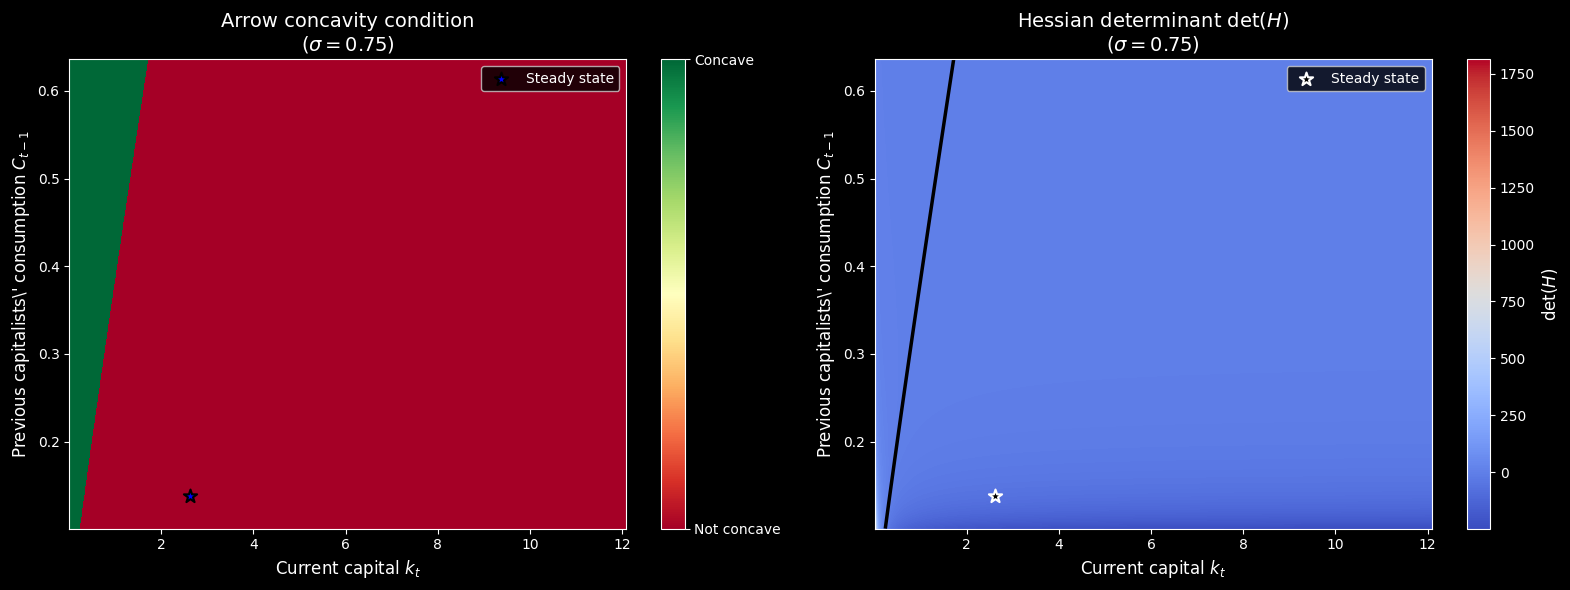

In [89]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ---- Subplot 1: Concavity region (green = Arrow condition holds) ----
im1 = ax1.pcolormesh(K, Z, is_concave, cmap='RdYlGn', shading='auto')
ax1.set_xlabel(r'Current capital $k_t$', fontsize=12)
ax1.set_ylabel(r'Previous capitalists\' consumption $C_{t-1}$', fontsize=12)
ax1.set_title(f'Arrow concavity condition\n($\\sigma = {sigma}$)', fontsize=14)

# Mark the steady state
ax1.scatter([k_star], [C_star], color='blue', s=100, marker='*',
            edgecolors='black', linewidth=1.5, label='Steady state')
ax1.legend(loc='upper right')

# Colorbar for the boolean map
cbar1 = plt.colorbar(im1, ax=ax1, ticks=[0, 1])
cbar1.set_ticklabels(['Not concave', 'Concave'])

# ---- Subplot 2: Determinant heatmap with zero contour line ----
im2 = ax2.pcolormesh(K, Z, det_clipped, cmap='coolwarm', shading='auto')
ax2.set_xlabel(r'Current capital $k_t$', fontsize=12)
ax2.set_ylabel(r'Previous capitalists\' consumption $C_{t-1}$', fontsize=12)
ax2.set_title(f'Hessian determinant $\\det(H)$\n($\\sigma = {sigma}$)', fontsize=14)

# ================  HERE IS THE ADDED LINE  ================
# Overlay a black contour line at det_H = 0 to split positive and negative regions
# Use the original (unclipped) det_H for accurate positioning
contour = ax2.contour(K, Z, det_H, levels=[0], colors='black', linewidths=2.5, linestyles='-')
# ===========================================================

# Mark the steady state
ax2.scatter([k_star], [C_star], color='black', s=100, marker='*',
            edgecolors='white', linewidth=1.5, label='Steady state')
ax2.legend(loc='upper right')

# Colorbar for determinant
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label(r'$\det(H)$', fontsize=12)

plt.tight_layout()
plt.show()